# TC 5033
## Advanced Machine Learning Methods
## Advanced Recurrent Networks and Language Models

### Team 30
- A01796272 - Luis Antonio Ramirez Martinez
- A01796323 - Benjamin Cisneros Barraza
- A01796363 - Arthur Jafed Zizumbo Velasco
- A01796937 - Sandra Luz Cervantes Espinoza

## TC 5033
### Word Embeddings

<br>

#### Activity 3a: Exploring Word Embeddings with GloVe and Numpy
<br>

- Objective:
    - To understand the concept of word embeddings and their significance in Natural Language Processing.
    - To learn how to manipulate and visualize high-dimensional data using dimensionality reduction techniques like PCA and t-SNE.
    - To gain hands-on experience in implementing word similarity and analogies using GloVe embeddings and Numpy.
    
<br>

- Instructions:
    - Download GloVe pre-trained vectors from the provided link in Canvas, the official public project: 
    Jeffrey Pennington, Richard Socher, and Christopher D. Manning. 2014. GloVe: Global Vectors for Word Representation
    https://nlp.stanford.edu/data/glove.6B.zip

    - Create a dictorionay of the embeddings so that you carry out fast look ups. Save that dictionary e.g. as a serialized file for faster loading in future uses.
    
    - PCA and t-SNE Visualization: After loading the GloVe embeddings, use Numpy and Sklearn to perform PCA and t-SNE to reduce the dimensionality of the embeddings and visualize them in a 2D or 3D space.

    - Word Similarity: Implement a function that takes a word as input and returns the 'n' most similar words based on their embeddings. You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Word Analogies: Implement a function to solve analogies between words. For example, "man is to king as woman is to ____". You should use Numpy to implement this function, using libraries that already implement this function (e.g. Gensim) will result in zero points.

    - Submission: This activity is to be submitted in teams of 3 or 4. Only one person should submit the final work, with the full names of all team members included in a markdown cell at the beginning of the notebook.
    
<br>

- Evaluation Criteria:

    - Code Quality (40%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity.
    
   - Functionality (60%): All functions should work as intended, without errors.
       - Visualization of PCA and t-SNE (10% each for a total of 20%)
       - Similarity function (20%)
       - Analogy function (20%)
|



#### Import Libraries

We import the following libraries:
- **numpy**: for vector math and cosine similarity computations
- **pickle**: to serialize and deserialize the embeddings dictionary for fast reuse
- **sklearn (PCA, TSNE)**: for dimensionality reduction and 2D visualization
- **matplotlib**: for plotting the embeddings
- **torch / torch.nn.functional**: available for optional tensor operations

In [151]:
# Import libraries
import torch
import torch.nn.functional as F
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
import pickle
plt.style.use('ggplot')

#### Load GloVe Embeddings

We use the **GloVe 6B 50-dimensional** pre-trained vectors (Jeffrey Pennington et al., 2014).  
Each line in the file follows the format:
```
word val1 val2 ... val50
```
We define the file path and embedding dimension as constants.

In [152]:
PATH = './glove_embeddings/glove.6B.50d.txt'
emb_dim = 50

In [153]:
# Create a dictionary that maps each token (word) to its embedding vector.
# Expected file format (common for embeddings like GloVe/word2vec text exports):
# Each line: <word> <f1> <f2> ... <fN>
# Example: "king 0.123 -0.045 ... 0.778"
def create_emb_dictionary(path):
    # Initialize an empty dictionary to hold word -> vector mappings
    embeddings_dict = {}

    # Open the embeddings file in text mode with UTF-8 encoding
    with open(path, 'r', encoding='utf-8') as f:
        # Iterate over the file line by line (memory-efficient for large files)
        for line in f:
            # Split the line by whitespace into tokens:
            # the first token is the word; the rest are numeric components
            values = line.split()

            # Extract the word (string)
            word = values[0]

            # Convert the remaining tokens to a NumPy float32 array (the embedding vector)
            vector = np.array(values[1:], dtype=np.float32)

            # Store the mapping in the dictionary
            embeddings_dict[word] = vector

    # Return the completed dictionary of embeddings
    return embeddings_dict

#### Building the Embeddings Dictionary

`create_emb_dictionary` reads the GloVe file line by line and builds a Python dictionary mapping each word to its embedding as a `numpy` array of `float32`.  
This allows **O(1) lookups** by word, which is critical for efficient similarity and analogy computations.

In [154]:
# create dictionary
embeddings_dict = create_emb_dictionary(PATH)

In [155]:
# Serialize
with open('embeddings_dict_50D.pkl', 'wb') as f:
    pickle.dump(embeddings_dict, f)

# Deserialize
# with open('embeddings_dict_200D.pkl', 'rb') as f:
#     embeddings_dict = pickle.load(f)

#### Serialization

We serialize the dictionary using `pickle` so it can be reloaded instantly in future sessions without re-parsing the GloVe text file.  
To reload, uncomment the deserialization block and comment out the `create_emb_dictionary` call above.

#### Inspecting the Embeddings

Before visualizing, we print the first few words and their raw vectors to verify the file was loaded correctly and confirm the embedding dimension (50).

In [156]:
# Utility to preview the first N lines of an embeddings-like text file.
# Each printed line shows:
#   1) The tokens in the line split by whitespace, and
#   2) The count of numeric components (i.e., vector length) after the first token.
#
# Expected line format (typical for word embeddings):
#   <word> <f1> <f2> ... <fN>
# Example:
#   king 0.123 -0.045 ... 0.778
def show_n_first_words(path, n_words):
    # Open the file in text mode (default encoding depends on system; use encoding='utf-8' if needed)
    with open(path, 'r') as f:
        # Iterate over lines with their index (i starts at 0)
        for i, line in enumerate(f):
            # Split the line into whitespace-separated tokens
            tokens = line.split()

            # Skip empty lines (avoid index errors and noisy output)
            if not tokens:
                continue

            # Print the tokens and the number of numeric elements after the first token (the word)
            # len(tokens[1:]) corresponds to the embedding vector dimensionality if the format is as expected.
            print(tokens, len(tokens[1:]))

            # Stop after printing the requested number of lines.
            # NOTE: Because i starts at 0, the condition `i >= n_words - 1` prints exactly n_words lines.
            if i >= n_words - 1:
                break


In [157]:
show_n_first_words(PATH, 5)

['the', '0.418', '0.24968', '-0.41242', '0.1217', '0.34527', '-0.044457', '-0.49688', '-0.17862', '-0.00066023', '-0.6566', '0.27843', '-0.14767', '-0.55677', '0.14658', '-0.0095095', '0.011658', '0.10204', '-0.12792', '-0.8443', '-0.12181', '-0.016801', '-0.33279', '-0.1552', '-0.23131', '-0.19181', '-1.8823', '-0.76746', '0.099051', '-0.42125', '-0.19526', '4.0071', '-0.18594', '-0.52287', '-0.31681', '0.00059213', '0.0074449', '0.17778', '-0.15897', '0.012041', '-0.054223', '-0.29871', '-0.15749', '-0.34758', '-0.045637', '-0.44251', '0.18785', '0.0027849', '-0.18411', '-0.11514', '-0.78581'] 50
[',', '0.013441', '0.23682', '-0.16899', '0.40951', '0.63812', '0.47709', '-0.42852', '-0.55641', '-0.364', '-0.23938', '0.13001', '-0.063734', '-0.39575', '-0.48162', '0.23291', '0.090201', '-0.13324', '0.078639', '-0.41634', '-0.15428', '0.10068', '0.48891', '0.31226', '-0.1252', '-0.037512', '-1.5179', '0.12612', '-0.02442', '-0.042961', '-0.28351', '3.5416', '-0.11956', '-0.014533', '-0.

### Dimensionality Reduction and Visualization

Word embeddings live in a 50-dimensional space, which is impossible to visualize directly. We use two complementary techniques to project them into 2D:

- **PCA** (Principal Component Analysis): a linear method that preserves global variance. Fast and deterministic.
- **t-SNE** (t-distributed Stochastic Neighbor Embedding): a non-linear method that preserves local neighborhood structure. Better at revealing clusters.

The function `plot_embeddings` accepts either technique via the `func` parameter.

In [158]:
def plot_embeddings(emb_path, words2show, emb_dim, embeddings_dict, func=PCA):
    """
    Plot a 2D projection of selected word embeddings and return the matrix used.

    Parameters
    ----------
    emb_path : str
        (Not used in the current implementation) Path to the embeddings file.
        The embeddings are expected to be provided via `embeddings_dict`.
    words2show : list[str]
        List of tokens/words to visualize.
    emb_dim : int
        Dimensionality of the original embedding vectors (e.g., 50, 100, 300).
    embeddings_dict : dict[str, np.ndarray]
        Mapping from word -> embedding vector (shape: [emb_dim]).
    func : callable
        A dimensionality reduction class with scikit-learn API (default: PCA).
        Must support `func(n_components=2, random_state=...)` and `.fit_transform(X)`.

    Returns
    -------
    np.ndarray
        The (N x emb_dim) array of embeddings assembled in the order of `words2show`,
        where N = len(words2show).
    """

    # Preallocate an array to hold the embeddings of the selected words
    # Shape: [number_of_words_to_show, embedding_dimension]
    embeddings = np.zeros((len(words2show), emb_dim))

    # Map each word to its row index in the `embeddings` matrix
    words2idx = {w: i for i, w in enumerate(words2show)}

    # (Unused) local dictionary — can be removed unless used later
    emb_dict = {}

    # Fill the `embeddings` matrix by fetching each word's vector from `embeddings_dict`
    for word in words2show:
        idx = words2idx[word]
        embeddings[idx] = embeddings_dict[word]

    # Reduce dimensionality to 2D for visualization using the chosen technique (PCA by default)
    # `random_state` is accepted by some methods (e.g., PCA ignores it, TSNE/UMAP use it).
    vectors_2d = func(n_components=2, random_state=43).fit_transform(embeddings)

    # Create a large figure for readability
    plt.figure(figsize=(20, 10))

    # Scatter plot of the 2D projections (one red point per word)
    # Note: Matplotlib may warn about `edgecolors` for unfilled markers; this is fine or change marker.
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='red', edgecolors='r')

    # Annotate each point with the corresponding word label
    for i, word in enumerate(words2show):
        plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]))

    # Render the plot
    plt.show()

    # Return the original high-dimensional embeddings matrix used for plotting
    return embeddings

In [159]:
words= ['burger', 'tortilla', 'bread', 'pizza', 'beef', 'steak', 'fries', 'chips', 
            'argentina', 'mexico', 'spain', 'usa', 'france', 'italy', 'greece', 'china',
            'water', 'beer', 'tequila', 'wine', 'whisky', 'brandy', 'vodka', 'coffee', 'tea',
            'apple', 'banana', 'orange', 'lemon', 'grapefruit', 'grape', 'strawberry', 'raspberry',
            'school', 'work', 'university', 'highschool',
            'teacher', 'student', 'professor', 'engineer', 'doctor', 'nurse', 'lawyer', 'artist',]


#### Word Selection

We select a set of semantically related words across multiple categories (foods, countries, drinks, fruits, academic/work contexts) to observe whether the embedding space places related words close together after dimensionality reduction.

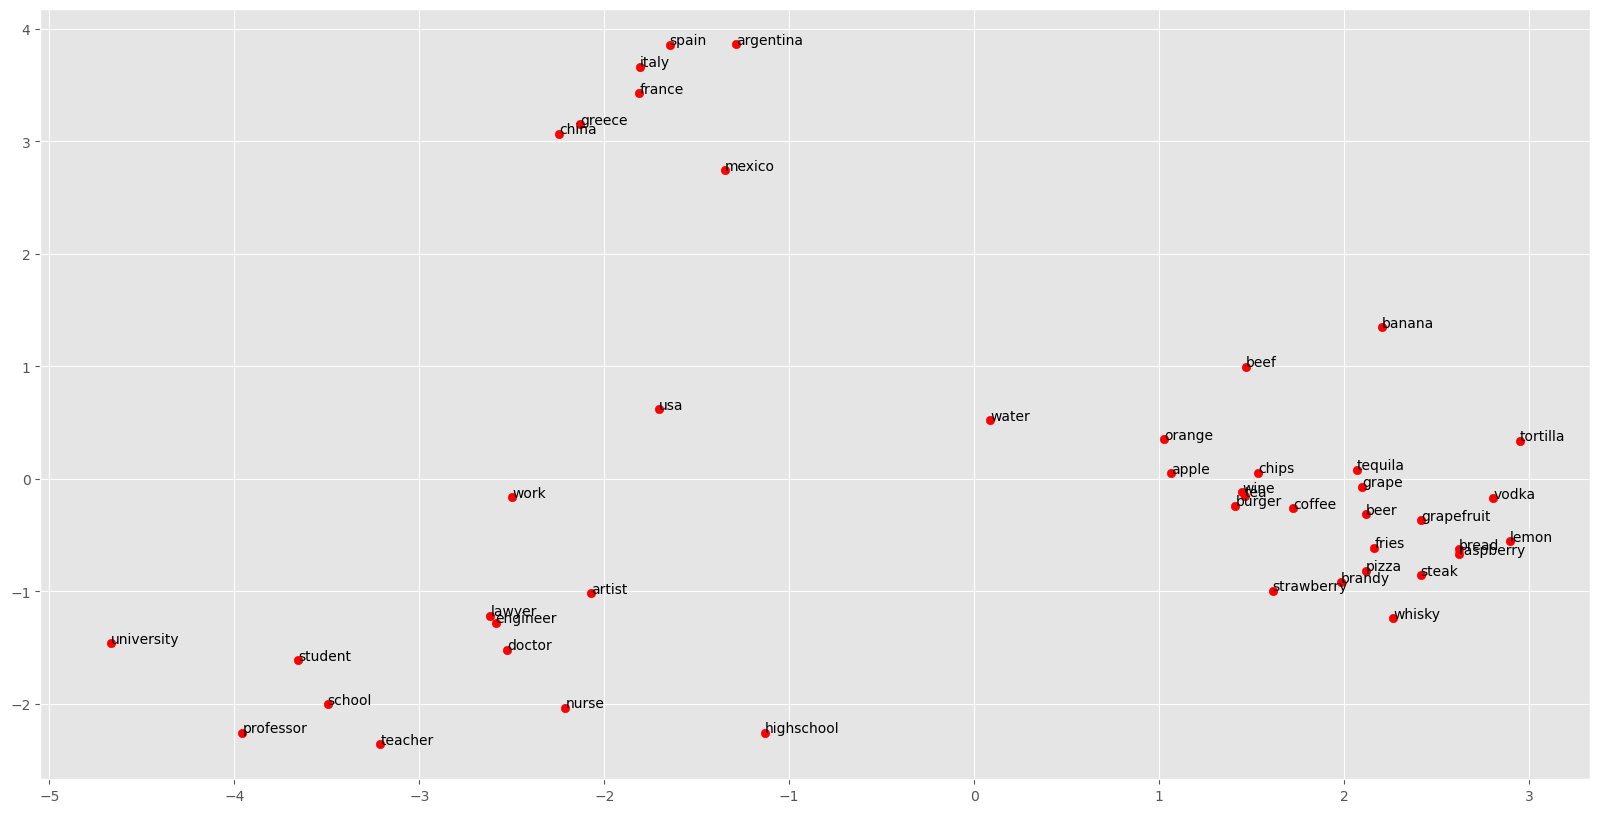

array([[ 0.36973   , -1.17970002, -0.92374998, ..., -0.54113001,
         0.21458   ,  0.81220001],
       [-0.80619001, -1.02450001, -0.28062001, ..., -0.47771001,
        -0.30274999,  0.012332  ],
       [-0.37436   , -0.11959   , -0.87608999, ..., -0.10138   ,
        -0.51134998, -0.18633001],
       ...,
       [ 0.36781999,  0.15792   , -0.74677998, ..., -0.63665003,
         0.016348  ,  1.4526    ],
       [-0.48076001, -0.024485  , -0.56514001, ..., -0.093861  ,
         0.1252    ,  0.99036002],
       [-0.91092998,  0.99808002, -0.71438998, ..., -1.34140003,
        -0.33598   ,  0.37173   ]], shape=(45, 50))

In [160]:
# 
plot_embeddings(PATH, words, emb_dim, embeddings_dict, PCA)

#### t-SNE Visualization

We now apply t-SNE to the same embeddings. Unlike PCA, t-SNE is stochastic and focuses on preserving **local structure**, often revealing tighter, more interpretable clusters.

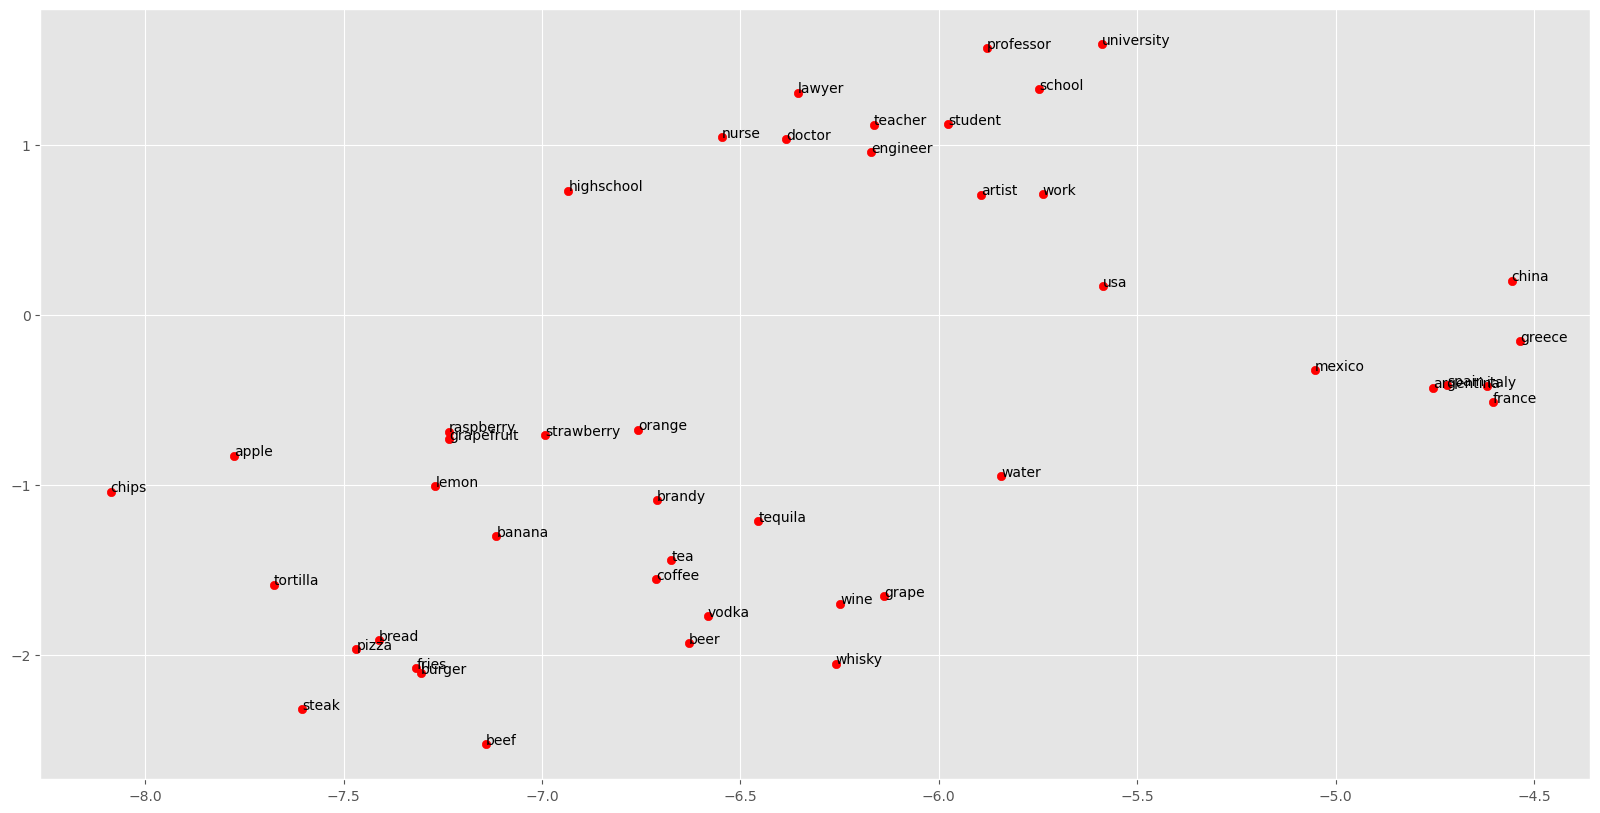

In [161]:
# t-SNE dimensionality reduction for visualization
embeddings = plot_embeddings(PATH, words, emb_dim, embeddings_dict, TSNE)

### Word Analogies

One of the most remarkable properties of word embeddings is that **semantic relationships can be expressed as vector arithmetic**.

For example:
> *"man is to king as woman is to ____"*  
> → `king − man + woman ≈ queen`

The `analogy(word1, word2, word3, embeddings_dict)` function:
1. Computes the target vector: `word2 − word1 + word3`
2. Finds the vocabulary word with the highest **cosine similarity** to that target
3. Excludes the three input words from the result

All computations are done with **numpy only** (no Gensim or similar libraries).

In [162]:
def prepare_normalized_matrix(
    embeddings_dict: Dict[str, np.ndarray],
    eps: float = 1e-12
) -> Tuple[Iterable[str], np.ndarray]:
    """
    Precompute and return:
      - the ordered list of words
      - the matrix of L2-normalized embedding vectors (shape: [vocab_size, emb_dim])

    Useful to speed up repeated analogy/similarity queries.
    """
    words = list(embeddings_dict.keys())
    vectors = np.array([embeddings_dict[w] for w in words], dtype=np.float32)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    vectors_norm = vectors / (norms + eps)
    return words, vectors_norm


def analogy(
    word1: str,
    word2: str,
    word3: str,
    embeddings_dict: Dict[str, np.ndarray],
    *,
    precomputed: Optional[Tuple[Iterable[str], np.ndarray]] = None,
    eps: float = 1e-12
) -> str:
    """
    Solve analogies of the form: word1 is to word2 as word3 is to _____.

    Parameters
    ----------
    word1, word2, word3 : str
        The three words forming the analogy prompt.
    embeddings_dict : dict[str, np.ndarray]
        Mapping from word -> embedding vector (shape: [emb_dim]).
    precomputed : optional (words, vectors_norm)
        Optional tuple with:
          - words: list of vocabulary strings in the same order as vectors_norm rows
          - vectors_norm: L2-normalized embedding matrix (shape: [vocab_size, emb_dim])
        Use this to avoid recomputing normalization for every call.
    eps : float
        Small constant for numerical stability when dividing by norms.

    Returns
    -------
    str
        A formatted string: "word1 is to word2 as word3 is to **best_word**"
    """

    # --- Robustness checks for existence and non-zero vectors ---
    for w in (word1, word2, word3):
        if w not in embeddings_dict:
            raise KeyError(f"'{w}' not found in embeddings_dict")
        if np.linalg.norm(embeddings_dict[w]) == 0:
            raise ValueError(f"Embedding for '{w}' has zero norm")

    # --- Fetch input vectors ---
    vec1 = embeddings_dict[word1]
    vec2 = embeddings_dict[word2]
    vec3 = embeddings_dict[word3]

    # Target vector via analogy arithmetic: vec2 - vec1 + vec3
    target = vec2 - vec1 + vec3

    # Normalize target to unit length (with epsilon to avoid divide-by-zero)
    target_norm = target / (np.linalg.norm(target) + eps)

    # --- Prepare normalized vocabulary matrix (use precomputed if provided) ---
    if precomputed is not None:
        words, vectors_norm = precomputed
        # Convert to list to allow index lookup
        if not isinstance(words, list):
            words = list(words)
    else:
        # Build normalized matrix on the fly (slower for repeated calls)
        words = list(embeddings_dict.keys())
        vectors = np.array([embeddings_dict[w] for w in words], dtype=np.float32)
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        vectors_norm = vectors / (norms + eps)

    # Cosine similarity reduces to dot product for normalized vectors
    similarities = vectors_norm @ target_norm  # shape: (vocab_size,)

    # Exclude the original words from being returned as the answer
    exclude = {word1, word2, word3}

    # Find the best matching word by scanning in descending similarity
    # Note: For very large vocabularies, you could use argpartition for top-k.
    best_word = None
    for idx in np.argsort(similarities)[::-1]:
        candidate = words[idx]
        if candidate not in exclude:
            best_word = candidate
            break

    if best_word is None:
        raise RuntimeError("No suitable analogy candidate found.")

    # Cleanly formatted output
    return f"{word1} is to {word2} as {word3} is to **{best_word}**"

In [163]:
print(analogy('man', 'king', 'woman', embeddings_dict))
print(analogy('earth', 'planet', 'car', embeddings_dict))
print(analogy('apple', 'fruit', 'potato', embeddings_dict))
print(analogy('short', 'tall', 'dark', embeddings_dict))
print(analogy('mexico', 'mexican', 'argentina', embeddings_dict))
print(analogy('apple', 'red', 'grape', embeddings_dict))
print(analogy('teacher', 'school', 'nurse', embeddings_dict))
print(analogy('programmer', 'computer', 'driver', embeddings_dict))
print(analogy('clock', 'time', 'thermometer', embeddings_dict))

man is to king as woman is to **queen**
earth is to planet as car is to **truck**
apple is to fruit as potato is to **vegetables**
short is to tall as dark is to **shade**
mexico is to mexican as argentina is to **argentine**
apple is to red as grape is to **yellow**
teacher is to school as nurse is to **hospital**
programmer is to computer as driver is to **car**
clock is to time as thermometer is to **degrees**


In [164]:
def prepare_normalized_matrix(
    embeddings_dict: Dict[str, np.ndarray],
    eps: float = 1e-12
) -> Tuple[List[str], np.ndarray]:
    """
    Precompute:
      - words: ordered vocabulary list
      - vectors_norm: L2-normalized embedding matrix [vocab_size, emb_dim]

    Useful for speeding up repeated similarity queries.
    """
    words = list(embeddings_dict.keys())
    vectors = np.array([embeddings_dict[w] for w in words], dtype=np.float32)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    vectors_norm = vectors / (norms + eps)
    return words, vectors_norm


def find_most_similar(
    word: str,
    embeddings_dict: Dict[str, np.ndarray],
    top_n: int = 10,
    *,
    precomputed: Optional[Tuple[Iterable[str], np.ndarray]] = None,
    eps: float = 1e-12
) -> List[Tuple[str, float]]:
    """
    Find the top-N most similar words to `word` using cosine similarity.

    Parameters
    ----------
    word : str
        Target word to query.
    embeddings_dict : dict[str, np.ndarray]
        Mapping word -> embedding vector.
    top_n : int
        Number of most similar words to return (excluding the word itself).
    precomputed : optional (words, vectors_norm)
        Optional tuple with (vocabulary list, normalized embedding matrix).
        Use this to avoid recomputing normalization on every call.
    eps : float
        Small constant to avoid divide-by-zero during normalization.

    Returns
    -------
    list[tuple[str, float]]
        List of (similar_word, cosine_similarity) sorted by similarity desc.
    """

    # --- Input checks for presence and non-zero norm ---
    if word not in embeddings_dict:
        raise KeyError(f"'{word}' not found in embeddings_dict")

    target = embeddings_dict[word]
    target_norm_val = np.linalg.norm(target)
    if target_norm_val == 0:
        raise ValueError(f"Embedding for '{word}' has zero norm")

    # Normalize target (cosine similarity)
    target_norm = target / (target_norm_val + eps)

    # --- Prepare normalized vocab matrix (use precomputed if provided) ---
    if precomputed is not None:
        words, vectors_norm = precomputed
        if not isinstance(words, list):
            words = list(words)
    else:
        words = list(embeddings_dict.keys())
        vectors = np.array([embeddings_dict[w] for w in words], dtype=np.float32)
        norms = np.linalg.norm(vectors, axis=1, keepdims=True)
        vectors_norm = vectors / (norms + eps)

    # Cosine similarity = dot product for normalized vectors
    similarities = vectors_norm @ target_norm  # shape: (vocab_size,)

    # Exclude the target word itself from results
    # For performance, compute top-(top_n+1) because the target may rank first
    k = min(top_n + 1, similarities.size)

    # Use argpartition to get top-k indices in O(n) average time
    candidate_idx = np.argpartition(similarities, -k)[-k:]
    # Fully sort just those candidates (descending)
    candidate_idx = candidate_idx[np.argsort(similarities[candidate_idx])[::-1]]

    results: List[Tuple[str, float]] = []
    for idx in candidate_idx:
        candidate_word = words[idx]
        if candidate_word == word:
            continue
        results.append((candidate_word, float(similarities[idx])))
        if len(results) == top_n:
            break

    return results


### Word Similarity

`find_most_similar(word, embeddings_dict, top_n)` retrieves the **top‑N most similar words** to a given input word using **cosine similarity**, where:

$$\text{similarity}(u, v) = \frac{u \cdot v}{\|u\| \cdot \|v\|}$$

The actual implementation includes several improvements for **robustness, numerical stability, and performance**:

#### 🔍 What the function does

1. **Validates input**
   - Ensures the target word exists in the embeddings.
   - Verifies that the embedding is not a zero vector.

2. **Normalizes embeddings**
   - The target vector is normalized using an epsilon for stability.
   - All vocabulary embeddings are normalized either:
     - **On the fly**, or  
     - **Via precomputed matrices** (recommended for many queries).

3. **Computes cosine similarities efficiently**
   - Uses a fast matrix–vector dot product:
     ```python
     similarities = vectors_norm @ target_norm
     ```

4. **Efficiently finds top candidates**
   - Uses `np.argpartition` for *O(n)* top‑k selection (faster than full sorting).
   - Then sorts only the small candidate set in descending order.

5. **Builds the final result**
   - Excludes the target word itself.
   - Returns a list of `(word, similarity_score)` tuples, sorted by similarity.

#### ✔️ Output Format

```python
[
    ("word1", similarity_score),
    ("word2", similarity_score),
    ...
]
```

> All similarity scores are cosine similarity values in the range [-1, 1].



In [165]:

# Optional precomputation (recommended for repeated queries)
words, vectors_norm = prepare_normalized_matrix(embeddings_dict)

most_similar = find_most_similar('mexico', embeddings_dict, precomputed=(words, vectors_norm))

In [166]:
for i, w in enumerate(most_similar, 1):
    print(f'{i} ---> {w[0]}')

1 ---> mexican
2 ---> venezuela
3 ---> colombia
4 ---> peru
5 ---> chile
6 ---> puerto
7 ---> rico
8 ---> cuba
9 ---> guatemala
10 ---> panama


In [167]:

query_words = ["mexico", "boy", "radio", "run", "teacher"]
top_n = 10

for qw in query_words:
    try:
        results = find_most_similar(
            qw,
            embeddings_dict,
            top_n=top_n,
            precomputed=(words, vectors_norm)
        )
        print(f"\nTop {top_n} most similar to '{qw}':")
        for rank, (w, score) in enumerate(results, start=1):
            print(f"{rank:2d}. {w:20s}  (cosine: {score:.4f})")
    except KeyError as e:
        print(f"\nSkipping '{qw}': {e}")



Top 10 most similar to 'mexico':
 1. mexican               (cosine: 0.8551)
 2. venezuela             (cosine: 0.8497)
 3. colombia              (cosine: 0.8490)
 4. peru                  (cosine: 0.8446)
 5. chile                 (cosine: 0.8439)
 6. puerto                (cosine: 0.8363)
 7. rico                  (cosine: 0.8195)
 8. cuba                  (cosine: 0.8125)
 9. guatemala             (cosine: 0.8114)
10. panama                (cosine: 0.8097)

Top 10 most similar to 'boy':
 1. girl                  (cosine: 0.9327)
 2. woman                 (cosine: 0.8596)
 3. man                   (cosine: 0.8564)
 4. kid                   (cosine: 0.8193)
 5. mother                (cosine: 0.8180)
 6. teenage               (cosine: 0.8030)
 7. baby                  (cosine: 0.8001)
 8. dad                   (cosine: 0.7851)
 9. her                   (cosine: 0.7837)
10. old                   (cosine: 0.7815)

Top 10 most similar to 'radio':
 1. broadcast             (cosine: 0.8736)